<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>RandomForestClassifier</h2>
</div>

In [51]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [52]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [54]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [55]:
X = df.drop(columns=['Default', 'LoanID'])#, 'DTIRatio', 'CreditScore'])
y = df['Default']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 16) (51070, 16) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [58]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [59]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder='passthrough'        
)

In [60]:
X_train = transformer.fit_transform(X_train)

In [61]:
X_test = transformer.transform(X_test)

In [62]:
from imblearn.over_sampling import SMOTE

In [63]:
smt = SMOTE()
xTrainSM, yTrainSM = smt.fit_resample(X_train, y_train)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. RandomForestClassifier</h2>
</div>

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
classifier = RandomForestClassifier(n_estimators=100, 
                            class_weight='balanced', 
                            random_state=42, 
                            n_jobs=-1, verbose=1)

In [66]:
classifier.fit(xTrainSM, yTrainSM)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.4s finished


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
                       verbose=1)

In [67]:
train_acc = classifier.score(X_train, y_train)
test_acc = classifier.score(X_test, y_test)

print(f'{"Training Accuracy:":<20}{train_acc:.2f}')
print(f'{"Test Accuracy:":<20}{test_acc:.2f}')

y_test_pred = classifier.predict(X_test)
print(f'{"Recall Score:":<20}{recall_score(y_test, y_test_pred, pos_label=1):.2f}')
print(f'{"Precision Score:":<20}{precision_score(y_test, y_test_pred, pos_label=1):.2f}')
print(f'{"RoC AuC Score:":<20}{roc_auc_score(y_test, y_test_pred):.2f}')
f1 = f1_score(y_test, y_test_pred, pos_label=1)
print(f'{"F1 Score:":<20}{f1:.2}')

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


Training Accuracy:  1.00
Test Accuracy:      0.89
Recall Score:       0.03
Precision Score:    0.63
RoC AuC Score:      0.51
F1 Score:           0.06


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished


In [68]:
y_pred = classifier.predict(X_test)

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished


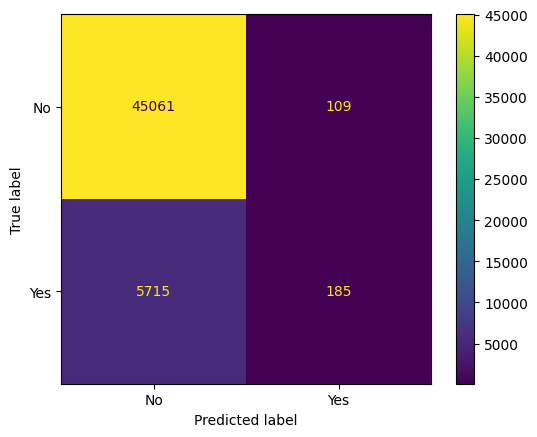

In [69]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [70]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
print(f"{'Recall Score:':<20}{rs:.3}")
print(f"{'Precision Score:':<20}{ps:.3}")
print(f"{'F1 Score:':<20}{f1:.3}")
print(f"{'ROC AUC Score:':<20}{roc:.3}")
print(f"{'Accuracy Score:':<20}{ac:.3}")

Recall Score:       0.0314
Precision Score:    0.629
F1 Score:           0.0597
ROC AUC Score:      0.514
Accuracy Score:     0.886


In [71]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(classifier, X_train, y_train, X_test, y_test)

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished


In [72]:
rs_list, ps_list, f1_list, ac_list = [],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    rs, ps, f1, ac, y_test_pred = calc_scores(classifier, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

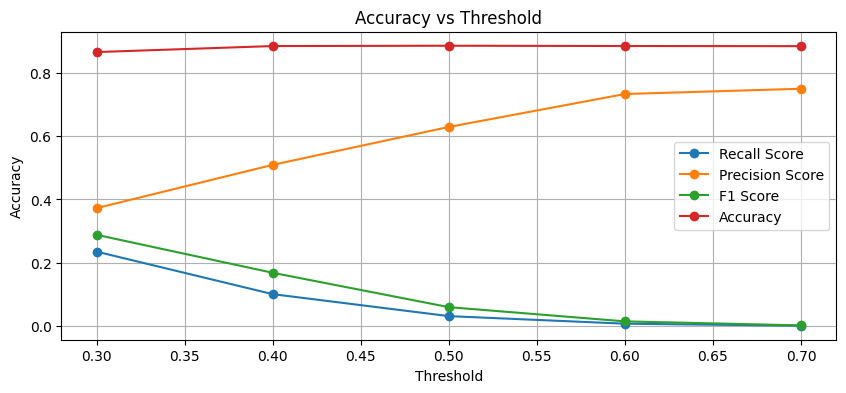

In [73]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("images/RandomForestClassifier.png")
plt.show()

In [74]:
pd.DataFrame({"recall": rs_list, "precision": ps_list, "f1-score": f1_list, "accuracy":ac_list}, index = np.arange(0.3,0.8,0.1))

,recall,precision,f1-score,accuracy
0.300,0.235,0.373,0.288,0.866
0.400,0.101,0.509,0.168,0.885
0.500,0.031,0.629,0.060,0.886
0.600,0.007,0.733,0.015,0.885
0.700,0.001,0.750,0.002,0.885


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>4. CatBoostClassifier</h2>
</div>

In [36]:
from catboost import CatBoostClassifier

In [37]:
pipeline = Pipeline([
    ('model', CatBoostClassifier(class_weights={0:1, 1:9}, random_state=42, verbose=0))  # Train Logistic Regression model
])

In [40]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7f0c140e1790>)])

In [49]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
print(f"{'Recall Score:':<20}{rs:.3}")
print(f"{'Precision Score:':<20}{ps:.3}")
print(f"{'F1 Score:':<20}{f1:.3}")
print(f"{'ROC AUC Score:':<20}{roc:.3}")
print(f"{'Accuracy Score:':<20}{ac:.3}")

Recall Score:       0.691
Precision Score:    0.219
F1 Score:           0.333
ROC AUC Score:      0.685
Accuracy Score:     0.68


In [42]:
y_pred = pipeline.predict(X_test)

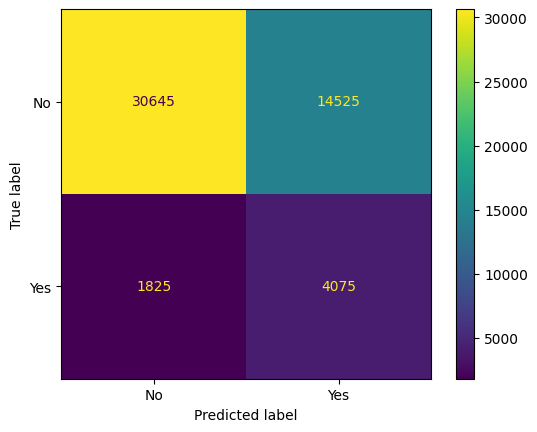

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [44]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(pipeline, X_train, y_train, X_test, y_test)

In [45]:
rs_list, ps_list, f1_list, ac_list = [],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    rs, ps, f1, ac, y_test_pred = calc_scores(pipeline, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

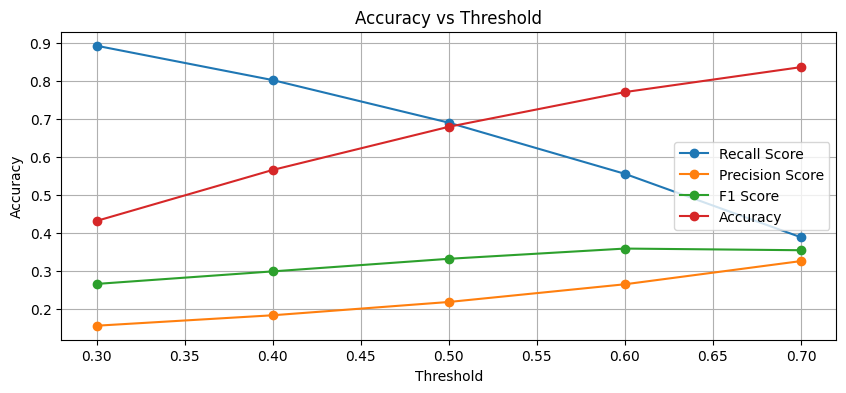

In [47]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("images/CatBoostClassifier-II.png")
plt.show()

In [46]:
pd.DataFrame({"recall": rs_list, "precision": ps_list, "f1-score": f1_list, "accuracy":ac_list}, index = np.arange(0.3,0.8,0.1))

,recall,precision,f1-score,accuracy
0.300,0.893,0.157,0.267,0.432
0.400,0.803,0.184,0.300,0.566
0.500,0.691,0.219,0.333,0.680
0.600,0.556,0.266,0.360,0.771
0.700,0.389,0.327,0.355,0.837
